<a href="https://colab.research.google.com/github/Omkar210/Statistics-and-ML/blob/main/NLP/Natural_Language_Processing_Day_27.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import re
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

nltk.download('averaged_perceptron_tagger_eng')#Pos tagging

nltk.download('maxent_ne_chunker_tab') #Chunking
nltk.download('words')
import pandas as pd
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.chunk import ne_chunk
import spacy
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

from wordcloud import WordCloud
import matplotlib.pyplot as plt

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


### Cleaning Text


In [ ]:
text = "Ruchika is teaching Natural Language Processing in Mumbai using Python."

clean_text = text.lower()
clean_text = re.sub(r'[^\w\s]', '', clean_text)
print(clean_text)


ruchika is teaching natural language processing in mumbai using python


### Tokenization

In [ ]:
tokens = word_tokenize(clean_text)
print(tokens)


['ruchika', 'is', 'teaching', 'natural', 'language', 'processing', 'in', 'mumbai', 'using', 'python']


### Removing StopWords

In [ ]:
stop_words = set(stopwords.words('english'))

filtered_tokens = [
    word for word in tokens
    if word not in stop_words
]
print(tokens)
print(filtered_tokens)


['ruchika', 'is', 'teaching', 'natural', 'language', 'processing', 'in', 'mumbai', 'using', 'python']
['ruchika', 'teaching', 'natural', 'language', 'processing', 'mumbai', 'using', 'python']


### Stemming

In [ ]:
stemmer = PorterStemmer()

stems = [stemmer.stem(word) for word in filtered_tokens]

for stem in stems:
  print(stem)



ruchika
teach
natur
languag
process
mumbai
use
python


### Lemmatization

In [ ]:
lemmatizer = WordNetLemmatizer()

lemmas = [
    lemmatizer.lemmatize(word)
    for word in filtered_tokens
]

for lemma in lemmas:
    print(lemma)



ruchika
teaching
natural
language
processing
mumbai
using
python


### POS Tagging

In [ ]:
original_tokens = word_tokenize(text)

pos_tags = pos_tag(original_tokens)

for word, tag in pos_tags:
    print(word,tag)


Ruchika NNP
is VBZ
teaching VBG
Natural NNP
Language NNP
Processing NNP
in IN
Mumbai NNP
using VBG
Python NNP
. .


Chunking(Shallow Parsing) Rule based grammar
Chunking identifies phrase structure (syntax), while NER identifies entity types (semantics).

In [ ]:

grammar = r"""
    NP: {<DT>?<JJ>*<NN.*>+}
    VP: {<VB.*><NP|PP>*}

"""
chunk_parser = nltk.RegexpParser(grammar)

chunk_tree = chunk_parser.parse(pos_tags)
print(chunk_tree)



(S
  (NP Ruchika/NNP)
  (VP is/VBZ)
  (VP teaching/VBG (NP Natural/NNP Language/NNP Processing/NNP))
  in/IN
  (NP Mumbai/NNP)
  (VP using/VBG (NP Python/NNP))
  ./.)


NER(input is always a pos_tag)

In [ ]:
ner_tree = ne_chunk(pos_tags)

print(ner_tree)

(S
  (GPE Ruchika/NNP)
  is/VBZ
  teaching/VBG
  (ORGANIZATION Natural/NNP Language/NNP)
  Processing/NNP
  in/IN
  (GPE Mumbai/NNP)
  using/VBG
  (PERSON Python/NNP)
  ./.)


NER using Spacy(tokenization,pos,ner automatically performed).

Deep parsing

In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm")

doc = nlp(text)

for ent in doc:
    print(ent.text, ent.pos_,ent.dep_,ent.head.text) #DEP stands for Dependency Relation .every word is connected to another word called its head.

Ruchika PROPN nsubj teaching
is AUX aux teaching
teaching VERB ROOT teaching
Natural PROPN compound Language
Language PROPN compound Processing
Processing NOUN dobj teaching
in ADP prep Processing
Mumbai PROPN pobj in
using VERB advcl teaching
Python PROPN dobj using
. PUNCT punct teaching


In [ ]:
# Sample documents
documents = [
    "I love NLP",
    "NLP is interesting",
    "I love machine learning"
]

# Create BoW model
vectorizer = CountVectorizer() #creates vocabulary


# Convert text into BoW matrix
X = vectorizer.fit_transform(documents)#counts occurances based on vocabulary

# Display as table
df = pd.DataFrame(
    X.toarray(),#sparse matrix to normal
    columns=vectorizer.get_feature_names_out()
)

print(df)

   interesting  is  learning  love  machine  nlp
0            0   0         0     1        0    1
1            1   1         0     0        0    1
2            0   0         1     1        1    0


TF:How often a word appears in a document \
IDF:Gives less importance to words appearing in many documents.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer


# Sample documents
documents = [
    "I love NLP",
    "NLP is interesting",
    "I love machine learning"
]

# Create TF-IDF model
vectorizer = TfidfVectorizer()

# Convert text into TF-IDF matrix
X = vectorizer.fit_transform(documents)

# Display as table
df = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)

print(df.round(2))

   interesting    is  learning  love  machine   nlp
0         0.00  0.00      0.00  0.71     0.00  0.71
1         0.62  0.62      0.00  0.00     0.00  0.47
2         0.00  0.00      0.62  0.47     0.62  0.00


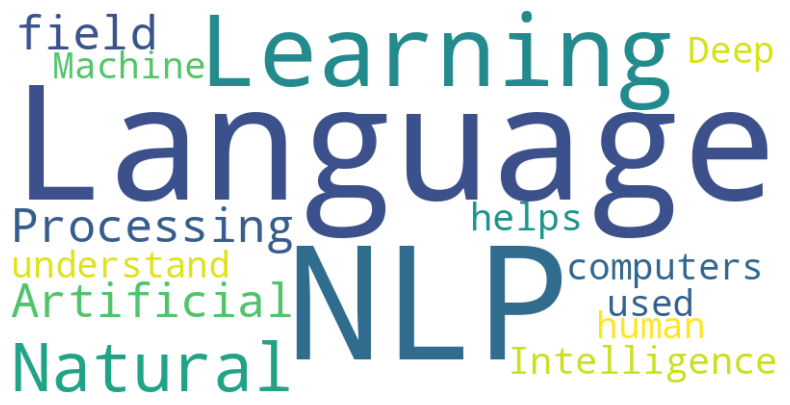

In [2]:
text = """
Natural Language Processing is a field of Artificial Intelligence.
NLP helps computers understand human language.
Machine Learning and Deep Learning are used in NLP.
"""

# Create word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

# Display
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()